# Regime switching (Markov switching)

A regime-switching series alternates between distinct dynamic *regimes* — bull/bear markets, expansion/recession — with switches governed by a hidden Markov chain. Each regime has its own mean and volatility, so the series changes character abruptly and persistently.

::: {.callout-note}
## The model

$$y_t = \mu_{s_t} + \phi_{s_t}\,(y_{t-1} - \mu_{s_t}) + \sigma_{s_t}\,\varepsilon_t, \qquad s_t \sim \text{Markov}(P)$$

A latent Markov chain over `n_regimes` states controls which dynamics generate each step; a transition matrix sets how sticky each regime is. The result is piecewise-stationary data with structural breaks that recur rather than happen once.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import RegimeSwitchingGenerator

## Bull/Bear market model

Define a two-regime model where the bull regime has positive mean and low variance,
while the bear regime has negative mean and high variance.

In [ ]:
params = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "n_regimes": 2,
    "regime_means": [0.05, -0.03],
    "regime_variances": [1.0, 4.0],
    "regime_ar_coeffs": [0.1, 0.2],
    "transition_matrix": [
        [0.98, 0.02],
        [0.10, 0.90],
    ],
    "seed": 42,
}

generator = RegimeSwitchingGenerator(engine="polars", **params)
df = generator.generate(n_series=3)

print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
df.head(10)

Generated 3 time series
Total observations: 1500


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,-0.855946
"""0""",2000-01-02 00:00:00,0.300061
"""0""",2000-01-03 00:00:00,-0.589824
"""0""",2000-01-04 00:00:00,-0.35486
"""0""",2000-01-05 00:00:00,0.190187
"""0""",2000-01-06 00:00:00,-0.131834
"""0""",2000-01-07 00:00:00,1.305301
"""0""",2000-01-08 00:00:00,-1.289682
"""0""",2000-01-09 00:00:00,1.136141


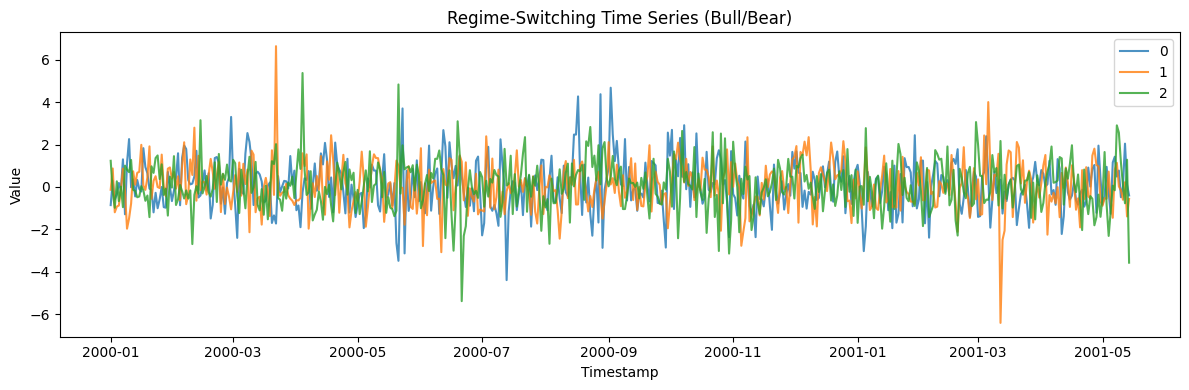

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Regime-Switching Time Series (Bull/Bear)")
ax.legend()
plt.tight_layout()
plt.show()

## Model information

Inspect model parameters including the stationary distribution of the Markov chain.

In [ ]:
info = generator.get_model_info()
print(f"Number of regimes: {info['n_regimes']}")
print(f"Regime means: {info['regime_means']}")
print(f"Regime variances: {info['regime_variances']}")
print(f"Stationary distribution: {[f'{p:.3f}' for p in info['stationary_distribution']]}")

Number of regimes: 2
Regime means: [0.05, -0.03]
Regime variances: [1.0, 4.0]
Stationary distribution: ['0.833', '0.167']


## Regime labels

Generate data with regime labels to see how observations are distributed across regimes.

In [ ]:
values, regimes, ids = generator.generate_with_regimes(n_series=1)
regime_counts = {0: (regimes == 0).sum(), 1: (regimes == 1).sum()}
print(f"Regime 0 (Bull) observations: {regime_counts[0]}")
print(f"Regime 1 (Bear) observations: {regime_counts[1]}")

Regime 0 (Bull) observations: 398
Regime 1 (Bear) observations: 102


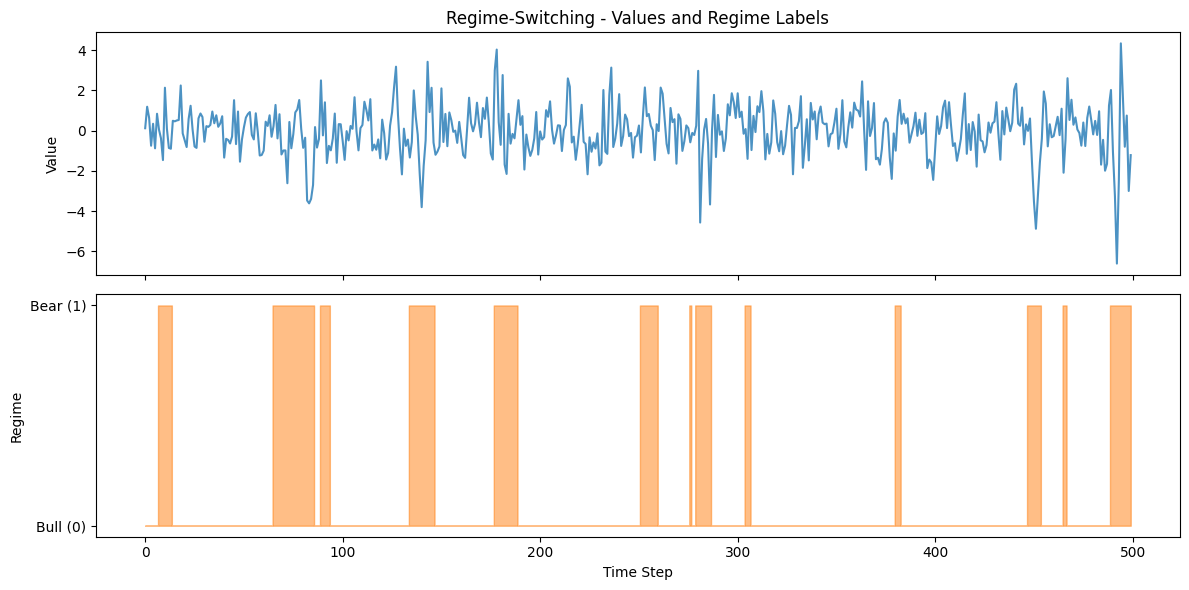

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(values, alpha=0.8)
axes[0].set_ylabel("Value")
axes[0].set_title("Regime-Switching - Values and Regime Labels")
axes[1].fill_between(range(len(regimes)), regimes, alpha=0.5, step="mid", color="tab:orange")
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Regime")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Bull (0)", "Bear (1)"])
plt.tight_layout()
plt.show()

## Statistics by series

Compare summary statistics across the generated series.

In [ ]:
stats = df.group_by("unique_id").agg(
    [
        pl.col("y").count().alias("count"),
        pl.col("y").min().alias("min_value"),
        pl.col("y").max().alias("max_value"),
        pl.col("y").mean().alias("mean_value"),
        pl.col("y").std().alias("std_value"),
    ]
)
stats

unique_id,count,min_value,max_value,mean_value,std_value
cat,u32,f64,f64,f64,f64
"""0""",500,-4.397419,4.687607,0.085832,1.1675
"""1""",500,-6.417219,6.649223,0.054715,1.114054
"""2""",500,-5.390482,5.381689,0.083175,1.140473


::: {.callout-tip}
## Related generators

- [Changepoints](../../capabilities/changepoints) — one-off structural breaks rather than recurring regimes.
- [GARCH](garch) — smoothly varying volatility instead of discrete states.

Regime and transition parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::